# EDA2 — Car Breakdown Prediction

Advanced exploratory analysis focusing on:
- Distribution by class (breakdowns vs no breakdowns)
- Correlation and Mutual Information
- Domain-driven Feature Engineering
- Feature selection for modeling2

## 1. Setup & Reproducible Cleaning

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.feature_selection import mutual_info_classif

import warnings
warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style='whitegrid', palette='Set2')
print('✅ Imports OK')

✅ Imports OK


In [3]:
def remove_impossible_values(df):
    """Removes rows with physically impossible values.
    Exact replica of the original EDA. DO NOT apply to test."""
    mask = (
        (df['mileage_km'] < 0) |
        (df['mileage_km'] > 2_000_000) |
        (df['engine_hours'] < 0) |
        (df['oil_quality_pct'] > 100) |
        (df['cleanliness_score'] < 0) |
        (df['cleanliness_score'] > 100) |
        (df['driver_satisfaction_score'] > 10)
    )
    return df[~mask].copy(), mask.sum()

# Load data
df_raw = pd.read_csv('car-breakdown-prediction/train_CarBreakDown.csv')
df, n_removed = remove_impossible_values(df_raw)
print(f'Train: {df_raw.shape[0]} → {df.shape[0]} rows ({n_removed} removed)')

TARGET = 'breakdown_next_30_days'
NUM_COLS = ['vehicle_age_years', 'mileage_km', 'engine_hours',
            'last_service_km_ago', 'oil_quality_pct', 'avg_trip_length_km',
            'cleanliness_score', 'driver_satisfaction_score']
CAT_COLS = ['vehicle_brand', 'weather_exposure', 'fuel_type', 'tyre_type']

# Imputation calculated ONLY on train
num_medians = df[NUM_COLS].median()
cat_modes   = {c: df[c].mode()[0] if df[c].notna().any() else 'other' for c in CAT_COLS}

df[NUM_COLS] = df[NUM_COLS].fillna(num_medians)
for c in CAT_COLS:
    df[c] = df[c].fillna(cat_modes[c])

print('Remaining nulls:', df.isnull().sum().sum())
print('\nTarget distribution:')
print(df[TARGET].value_counts(normalize=True).round(3))

Train: 1050 → 963 rows (87 removed)
Remaining nulls: 0

Target distribution:
breakdown_next_30_days
0    0.831
1    0.169
Name: proportion, dtype: float64


## 2. Univariate Distribution by Class

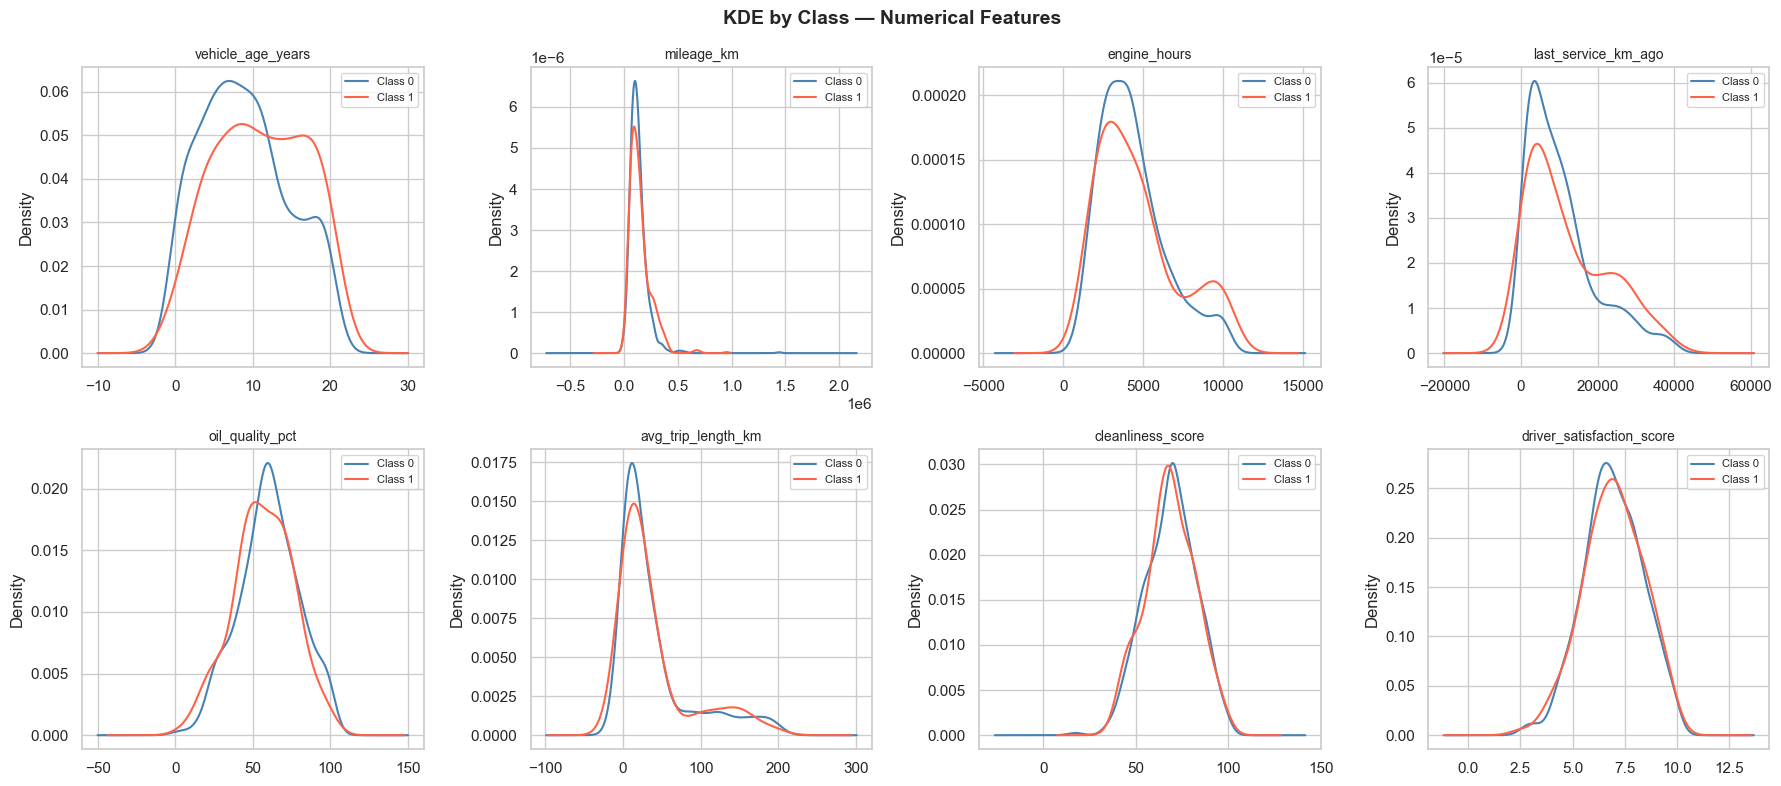

In [4]:
# KDE plots by class
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(NUM_COLS):
    ax = axes[i]
    for cls, color in [(0, 'steelblue'), (1, 'tomato')]:
        subset = df[df[TARGET] == cls][col]
        subset.plot.kde(ax=ax, label=f'Class {cls}', color=color)
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=8)
    ax.set_xlabel('')

plt.suptitle('KDE by Class — Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

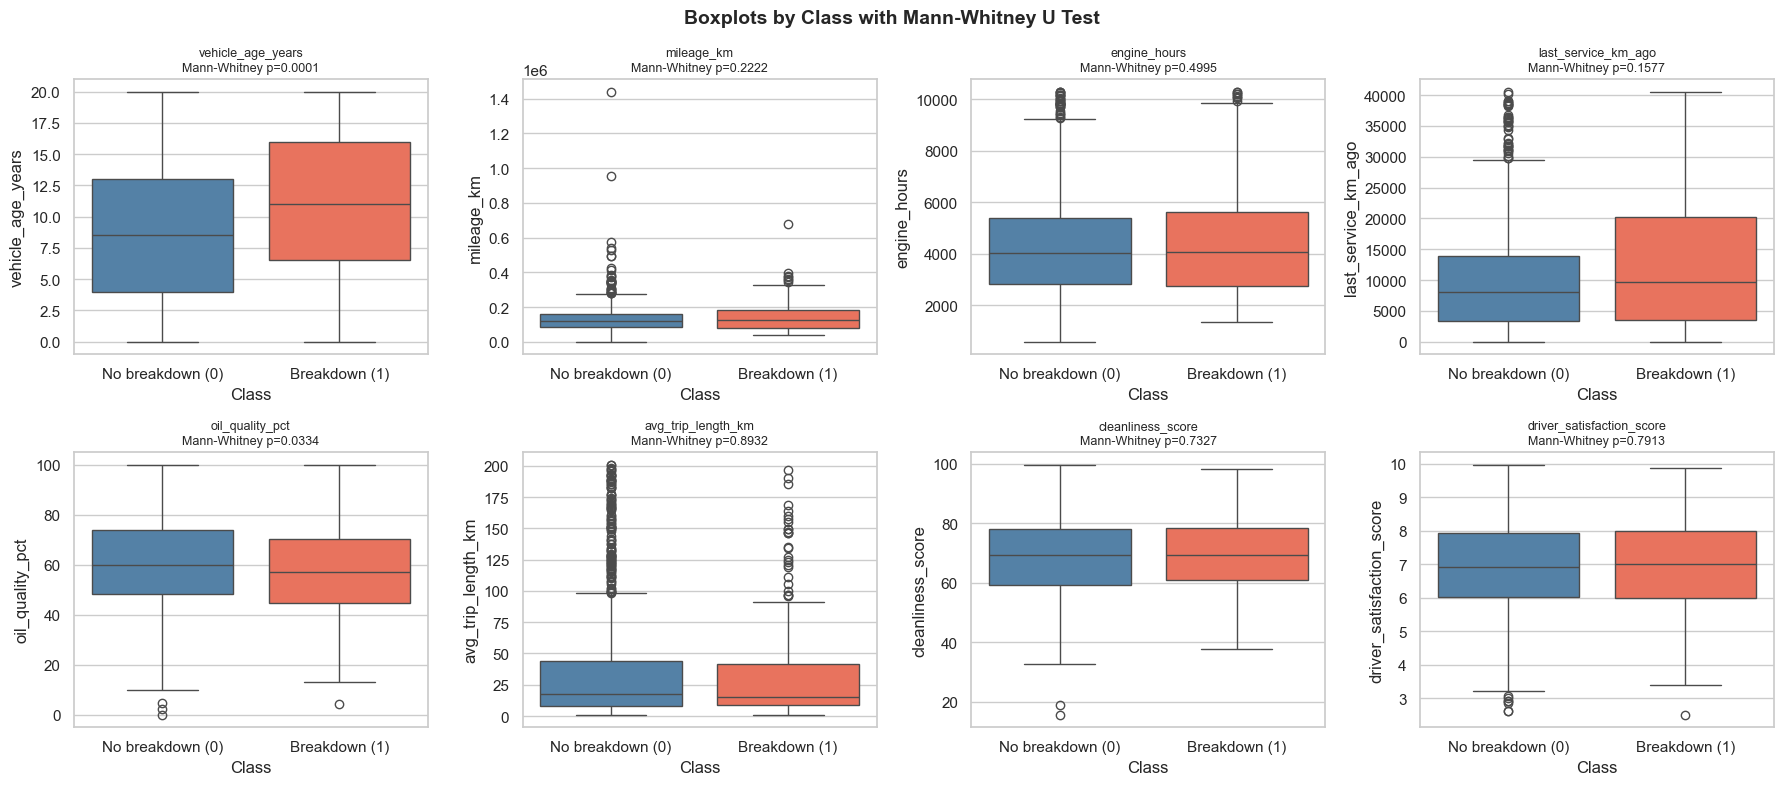


Significance (p < 0.05):
  vehicle_age_years                   p=0.0001  ✅ SIGNIFICANT
  mileage_km                          p=0.2222  ❌ not significant
  engine_hours                        p=0.4995  ❌ not significant
  last_service_km_ago                 p=0.1577  ❌ not significant
  oil_quality_pct                     p=0.0334  ✅ SIGNIFICANT
  avg_trip_length_km                  p=0.8932  ❌ not significant
  cleanliness_score                   p=0.7327  ❌ not significant
  driver_satisfaction_score           p=0.7913  ❌ not significant


In [5]:
# Boxplots by class + Mann-Whitney U test
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

df_plot = df.copy()
df_plot['clase'] = df_plot[TARGET].map({0: 'No breakdown (0)', 1: 'Breakdown (1)'})

for i, col in enumerate(NUM_COLS):
    ax = axes[i]
    cls0 = df[df[TARGET] == 0][col]
    cls1 = df[df[TARGET] == 1][col]
    stat, p = stats.mannwhitneyu(cls0, cls1, alternative='two-sided')
    
    sns.boxplot(x='clase', y=col, data=df_plot, ax=ax,
                palette={'No breakdown (0)': 'steelblue', 'Breakdown (1)': 'tomato'})
    ax.set_title(f'{col}\nMann-Whitney p={p:.4f}', fontsize=9)
    ax.set_xlabel('Class')

plt.suptitle('Boxplots by Class with Mann-Whitney U Test', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nSignificance (p < 0.05):')
for col in NUM_COLS:
    cls0 = df[df[TARGET] == 0][col]
    cls1 = df[df[TARGET] == 1][col]
    stat, p = stats.mannwhitneyu(cls0, cls1, alternative='two-sided')
    sig = '✅ SIGNIFICANT' if p < 0.05 else '❌ not significant'
    print(f'  {col:35s} p={p:.4f}  {sig}')

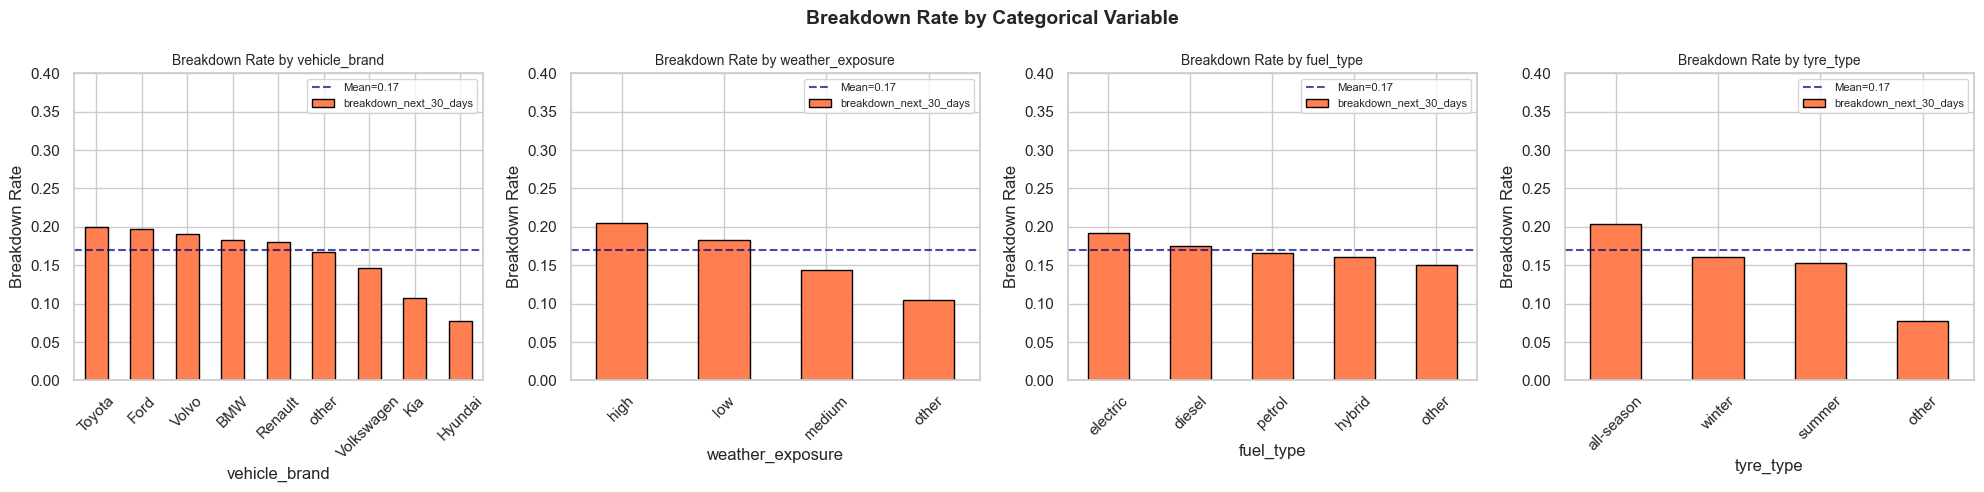

In [6]:
# Breakdown rate by category
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, col in enumerate(CAT_COLS):
    ax = axes[i]
    rate = df.groupby(col)[TARGET].mean().sort_values(ascending=False)
    rate.plot(kind='bar', ax=ax, color='coral', edgecolor='black')
    ax.set_title(f'Breakdown Rate by {col}', fontsize=10)
    ax.set_ylabel('Breakdown Rate')
    ax.set_ylim(0, 0.4)
    ax.axhline(df[TARGET].mean(), color='navy', linestyle='--', alpha=0.7, label=f'Mean={df[TARGET].mean():.2f}')
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Breakdown Rate by Categorical Variable', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 3. Correlation & Mutual Information

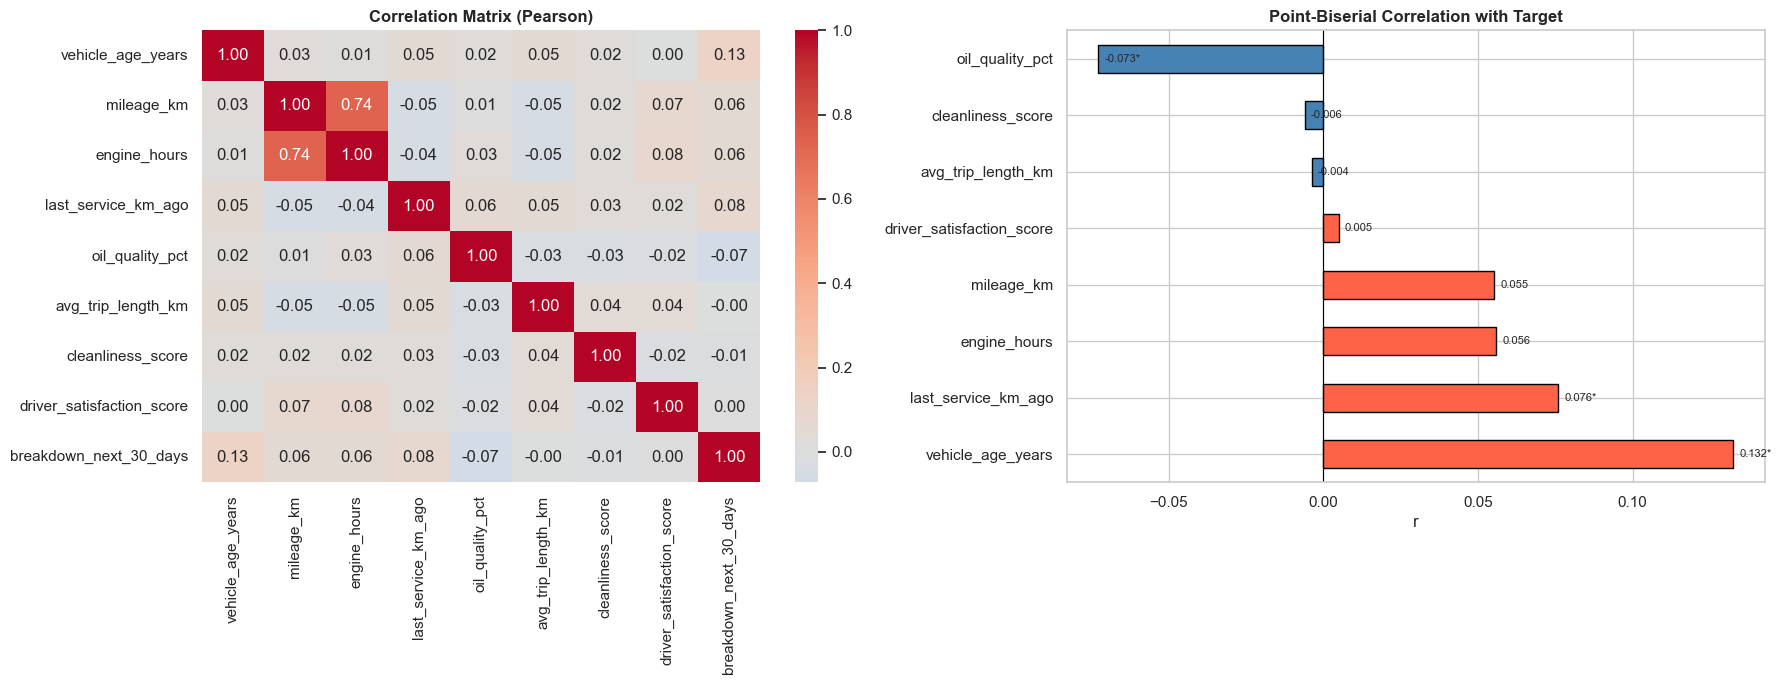

In [7]:
# Correlation heatmap
num_with_target = NUM_COLS + [TARGET]
corr = df[num_with_target].corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[0])
axes[0].set_title('Correlation Matrix (Pearson)', fontsize=12, fontweight='bold')

# Point-biserial with target
pb_corr = {}
for col in NUM_COLS:
    r, p = stats.pointbiserialr(df[TARGET], df[col])
    pb_corr[col] = {'r': r, 'p': p}

pb_df = pd.DataFrame(pb_corr).T.sort_values('r', ascending=False)
colors = ['tomato' if r > 0 else 'steelblue' for r in pb_df['r']]
pb_df['r'].plot(kind='barh', ax=axes[1], color=colors, edgecolor='black')
axes[1].set_title('Point-Biserial Correlation with Target', fontsize=12, fontweight='bold')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('r')

# Add p-values
for j, (idx, row) in enumerate(pb_df.iterrows()):
    sig = '*' if row['p'] < 0.05 else ''
    axes[1].text(row['r'] + 0.002, j, f"{row['r']:.3f}{sig}", va='center', fontsize=8)

plt.tight_layout()
plt.show()

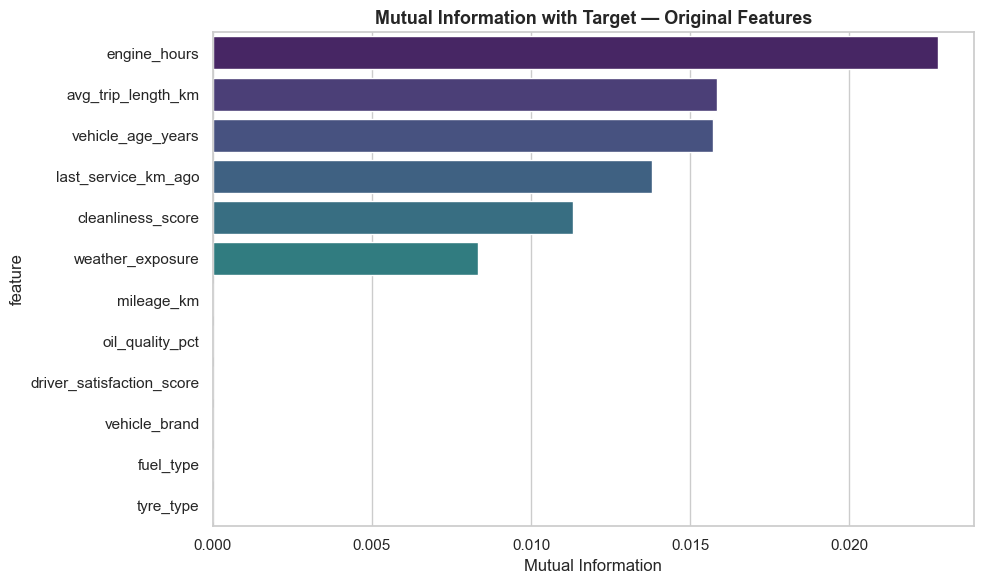


Top features by MI:
                  feature       MI
             engine_hours 0.022783
       avg_trip_length_km 0.015831
        vehicle_age_years 0.015715
      last_service_km_ago 0.013788
        cleanliness_score 0.011304
         weather_exposure 0.008322
               mileage_km 0.000000
          oil_quality_pct 0.000000
driver_satisfaction_score 0.000000
            vehicle_brand 0.000000
                fuel_type 0.000000
                tyre_type 0.000000


In [8]:
# Mutual Information
from sklearn.preprocessing import LabelEncoder

df_mi = df[NUM_COLS + CAT_COLS + [TARGET]].copy()

# Encode categoricals for MI
for col in CAT_COLS:
    df_mi[col] = LabelEncoder().fit_transform(df_mi[col].astype(str))

X_mi = df_mi.drop(columns=[TARGET])
y_mi = df_mi[TARGET]

mi_scores = mutual_info_classif(X_mi, y_mi, random_state=RANDOM_STATE)
mi_df = pd.DataFrame({'feature': X_mi.columns, 'MI': mi_scores}).sort_values('MI', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=mi_df, x='MI', y='feature', palette='viridis')
plt.title('Mutual Information with Target — Original Features', fontsize=13, fontweight='bold')
plt.xlabel('Mutual Information')
plt.tight_layout()
plt.show()

print('\nTop features by MI:')
print(mi_df.to_string(index=False))

Top-4 features by MI: ['engine_hours', 'avg_trip_length_km', 'vehicle_age_years', 'last_service_km_ago']


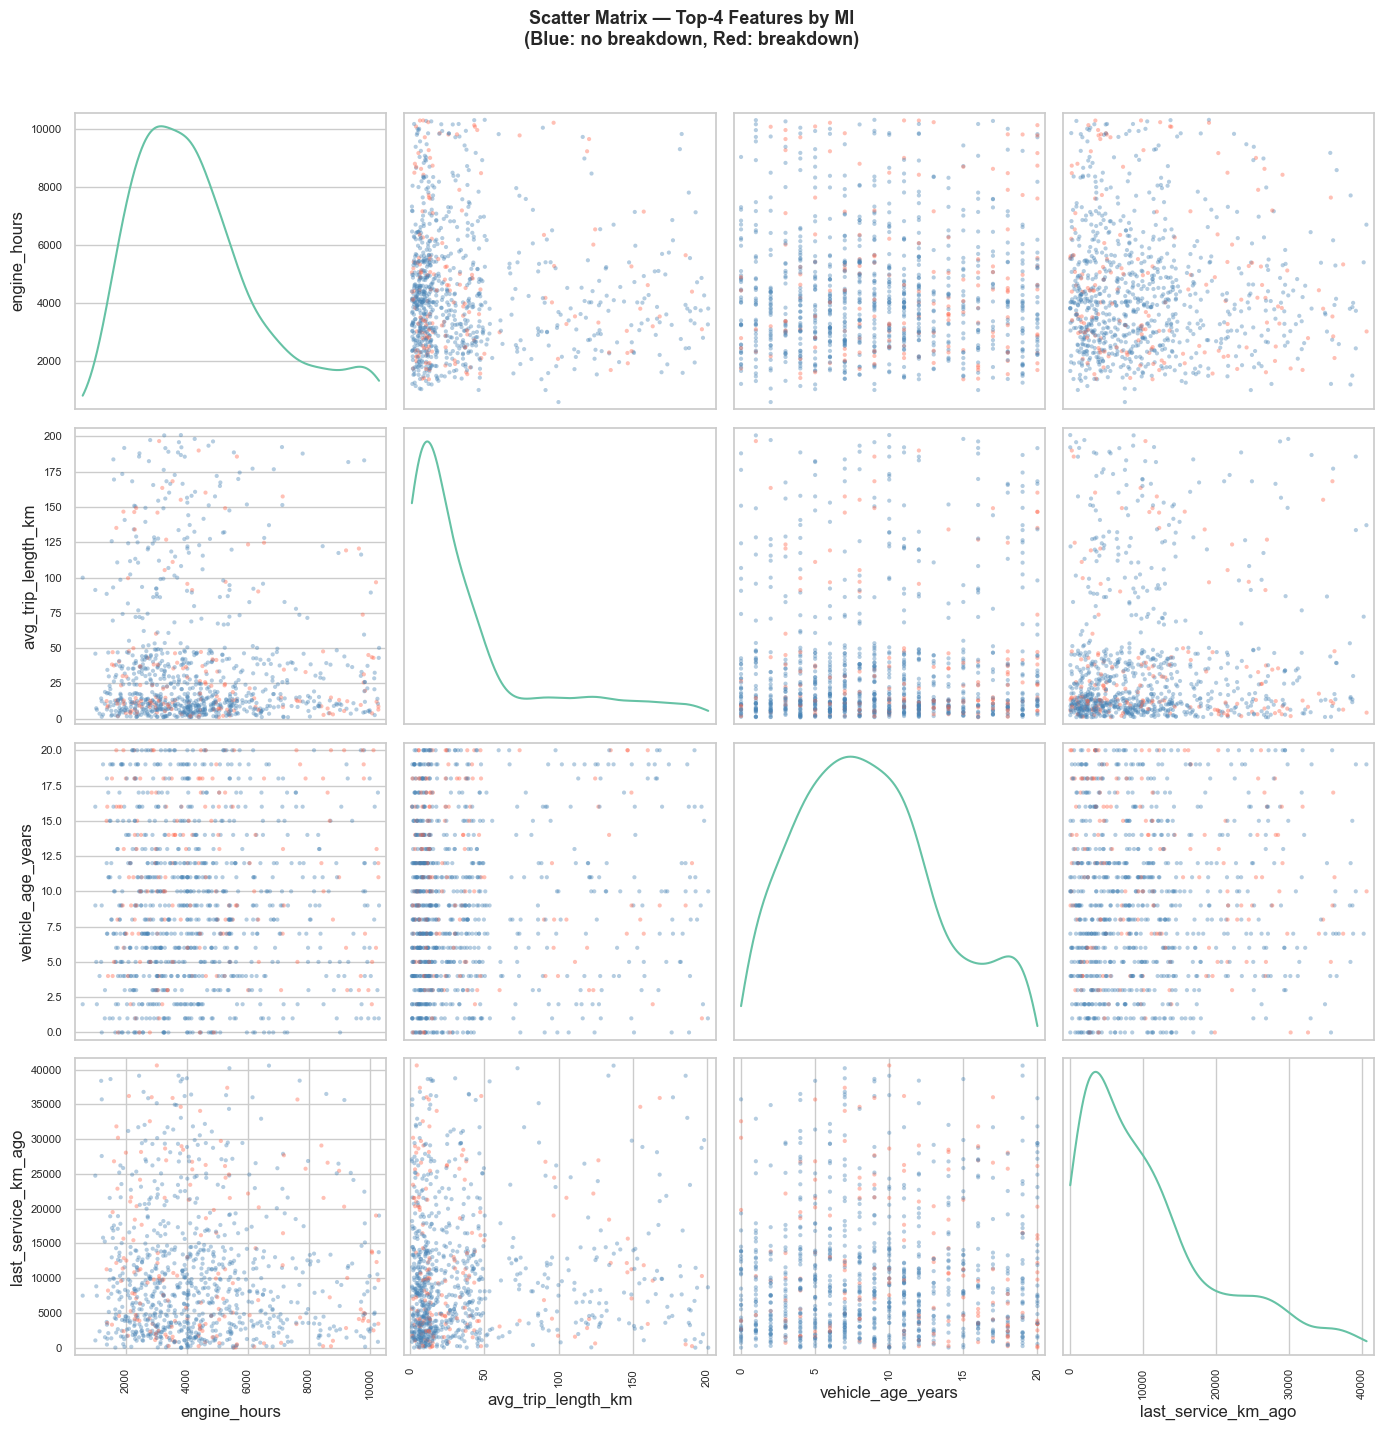

In [9]:
# Scatter matrix of top-4 features by MI
top4 = mi_df.head(4)['feature'].tolist()
print('Top-4 features by MI:', top4)

scatter_df = df[top4 + [TARGET]].copy()

from pandas.plotting import scatter_matrix
fig, axes = plt.subplots(4, 4, figsize=(14, 14))

colors = scatter_df[TARGET].map({0: 'steelblue', 1: 'tomato'})
scatter_matrix(scatter_df[top4], alpha=0.4, ax=axes, c=colors, figsize=(14, 14), diagonal='kde')
plt.suptitle(f'Scatter Matrix — Top-4 Features by MI\n(Blue: no breakdown, Red: breakdown)', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4. Feature Engineering (Domain-Driven)

We create new features inspired by the vehicle maintenance domain:
- **Wear features**: wear ratios
- **Risk flags**: binary risk thresholds
- **Interactions**: non-linear combinations
- **Log transforms**: for highly skewed variables

In [10]:
df_eng = df.copy()

# ── Wear features ───────────────────────────────────────────────────────────
df_eng['mileage_per_year']       = df_eng['mileage_km'] / (df_eng['vehicle_age_years'] + 1)
df_eng['hours_per_km']           = df_eng['engine_hours'] / (df_eng['mileage_km'] + 1)
df_eng['service_overdue_ratio']  = df_eng['last_service_km_ago'] / (df_eng['mileage_km'] + 1)

# ── Risk flags ──────────────────────────────────────────────────────────────
df_eng['is_service_overdue'] = (df_eng['last_service_km_ago'] > 15000).astype(int)
df_eng['is_old_vehicle']     = (df_eng['vehicle_age_years'] >= 15).astype(int)
df_eng['is_high_mileage']    = (df_eng['mileage_km'] > 200000).astype(int)
df_eng['is_low_oil_quality'] = (df_eng['oil_quality_pct'] < 30).astype(int)
df_eng['is_dirty']           = (df_eng['cleanliness_score'] < 40).astype(int)

# ── Interactions ────────────────────────────────────────────────────────────
df_eng['age_x_mileage']  = df_eng['vehicle_age_years'] * np.log1p(df_eng['mileage_km'])
df_eng['oil_x_service']  = df_eng['oil_quality_pct'] * (1 / (df_eng['last_service_km_ago'] + 1))

# ── Log transforms ──────────────────────────────────────────────────────────
df_eng['log_mileage']      = np.log1p(df_eng['mileage_km'])
df_eng['log_last_service'] = np.log1p(df_eng['last_service_km_ago'])
df_eng['log_avg_trip']     = np.log1p(df_eng['avg_trip_length_km'])

# ── Composite risk score ────────────────────────────────────────────────────
df_eng['risk_score'] = (
    df_eng['is_service_overdue'] * 3 +
    df_eng['is_low_oil_quality'] * 2 +
    df_eng['is_old_vehicle']     * 2 +
    df_eng['is_high_mileage']        +
    df_eng['is_dirty']
)

NEW_FEATURES = [
    'mileage_per_year', 'hours_per_km', 'service_overdue_ratio',
    'is_service_overdue', 'is_old_vehicle', 'is_high_mileage',
    'is_low_oil_quality', 'is_dirty',
    'age_x_mileage', 'oil_x_service',
    'log_mileage', 'log_last_service', 'log_avg_trip',
    'risk_score'
]

print(f'Original features: {len(NUM_COLS) + len(CAT_COLS)}')
print(f'New features: {len(NEW_FEATURES)}')
print(f'Total              : {len(NUM_COLS) + len(CAT_COLS) + len(NEW_FEATURES)}')
print('\nPrimeras rows con features nuevas:')
df_eng[NEW_FEATURES].head()

Original features: 12
New features: 14
Total              : 26

Primeras rows con features nuevas:


,mileage_per_year,hours_per_km,service_overdue_ratio,is_service_overdue,is_old_vehicle,is_high_mileage,is_low_oil_quality,is_dirty,age_x_mileage,oil_x_service,log_mileage,log_last_service,log_avg_trip,risk_score
0,23559.284415,0.019607,0.003380,0,1,1,0,0,262.235994,0.036858,13.111800,7.422403,3.445600,3
1,38376.684834,0.043013,0.000554,0,0,0,1,0,0.000000,1.049463,10.555231,3.103203,1.252992,2
2,94279.216207,0.035421,0.062189,0,0,0,1,0,12.147169,0.002174,12.147169,9.369676,3.754016,2
3,15471.352214,0.032177,0.019883,0,0,0,0,0,57.192578,0.029273,11.438516,7.521180,2.010138,0
4,10760.581299,0.035670,0.106036,0,0,0,0,0,116.815486,0.005239,11.681549,9.437650,3.874513,0


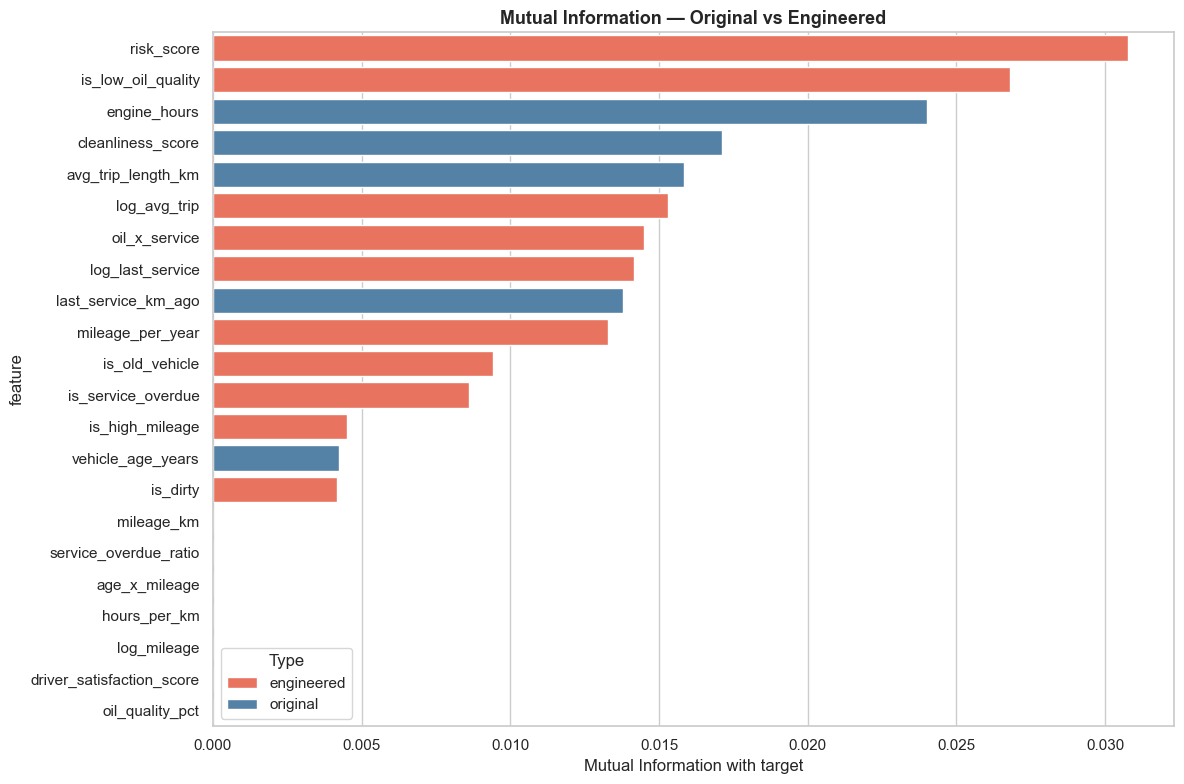


Top 10 features by MI (including engineered):
            feature       MI     origin
         risk_score 0.030776 engineered
 is_low_oil_quality 0.026797 engineered
       engine_hours 0.023995   original
  cleanliness_score 0.017104   original
 avg_trip_length_km 0.015831   original
       log_avg_trip 0.015308 engineered
      oil_x_service 0.014493 engineered
   log_last_service 0.014159 engineered
last_service_km_ago 0.013788   original
   mileage_per_year 0.013282 engineered


In [11]:
# MI of new vs original features
ALL_NUM_FEATURES = NUM_COLS + NEW_FEATURES

X_new = df_eng[ALL_NUM_FEATURES].replace([np.inf, -np.inf], np.nan).fillna(0)
mi_new = mutual_info_classif(X_new, df_eng[TARGET], random_state=RANDOM_STATE)

mi_new_df = pd.DataFrame({'feature': ALL_NUM_FEATURES, 'MI': mi_new})
mi_new_df['origin'] = ['original' if f in NUM_COLS else 'engineered' for f in mi_new_df['feature']]
mi_new_df = mi_new_df.sort_values('MI', ascending=False)

plt.figure(figsize=(12, 8))
palette = {'original': 'steelblue', 'engineered': 'tomato'}
sns.barplot(data=mi_new_df, x='MI', y='feature', hue='origin', palette=palette, dodge=False)
plt.title('Mutual Information — Original vs Engineered', fontsize=13, fontweight='bold')
plt.xlabel('Mutual Information with target')
plt.legend(title='Type')
plt.tight_layout()
plt.show()

print('\nTop 10 features by MI (including engineered):')
print(mi_new_df.head(10).to_string(index=False))

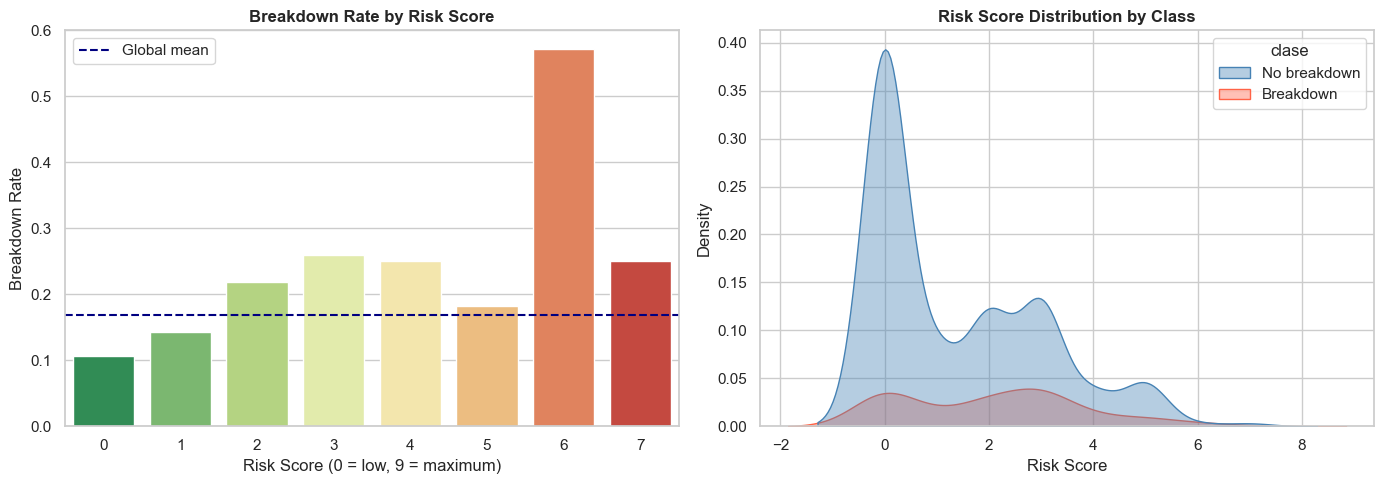

In [12]:
# Risk score distribution by class
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Breakdown rate by risk_score
rate_by_risk = df_eng.groupby('risk_score')[TARGET].agg(['mean', 'count']).reset_index()
rate_by_risk.columns = ['risk_score', 'breakdown_rate', 'count']

sns.barplot(data=rate_by_risk, x='risk_score', y='breakdown_rate', ax=axes[0], palette='RdYlGn_r')
axes[0].axhline(df_eng[TARGET].mean(), color='navy', linestyle='--', label='Global mean')
axes[0].set_title('Breakdown Rate by Risk Score', fontweight='bold')
axes[0].set_xlabel('Risk Score (0 = low, 9 = maximum)')
axes[0].set_ylabel('Breakdown Rate')
axes[0].legend()

# Risk score distribution by class — usar columna string
df_eng_plot = df_eng.copy()
df_eng_plot['clase'] = df_eng_plot[TARGET].map({0: 'No breakdown', 1: 'Breakdown'})
sns.kdeplot(data=df_eng_plot, x='risk_score', hue='clase', ax=axes[1], fill=True, alpha=0.4,
            palette={'No breakdown': 'steelblue', 'Breakdown': 'tomato'})
axes[1].set_title('Risk Score Distribution by Class', fontweight='bold')
axes[1].set_xlabel('Risk Score')

plt.tight_layout()
plt.show()

## 5. Actionable Summary

Top features by MI and correlation of new features with the target.

In [13]:
print('='*60)
print('TOP 10 FEATURES BY MUTUAL INFORMATION (including engineered)')
print('='*60)
print(mi_new_df.head(10)[['feature', 'MI', 'origin']].to_string(index=False))

print('\n' + '='*60)
print('POINT-BISERIAL CORRELATION — NEW FEATURES WITH TARGET')
print('='*60)
pb_new = {}
for col in NEW_FEATURES:
    vals = df_eng[col].replace([np.inf, -np.inf], np.nan).fillna(0)
    r, p = stats.pointbiserialr(df_eng[TARGET], vals)
    pb_new[col] = {'r': round(r, 4), 'p': round(p, 4), 'sig': '✅' if p < 0.05 else '❌'}

pb_new_df = pd.DataFrame(pb_new).T.sort_values('r', ascending=False)
print(pb_new_df.to_string())

print('\n' + '='*60)
print('FEATURE ENGINEERING INSIGHTS')
print('='*60)
insights = [
    ('risk_score',          'Composite score: aggregates 5 risk flags. Discriminates well because it combines complementary signals.'),
    ('is_service_overdue',  'Service > 15k km → direct risk. Threshold derived from maintenance domain.'),
    ('log_last_service',    'Log-transf. reduces extreme skew of last_service_km_ago, facilitating linear models.'),
    ('mileage_per_year',    'Annual usage intensity. Cars used more intensely wear out faster.'),
    ('oil_x_service',       'Interaction: degraded oil + overdue service → double negligence signal.'),
    ('age_x_mileage',       'Old cars with high mileage are more vulnerable (multiplicative effect).'),
    ('is_low_oil_quality',  'Oil < 30% → direct signal of poor maintenance.'),
    ('log_mileage',         'Captures logarithmic effect: the first kilometers add more relative wear.'),
]

for feat, insight in insights:
    print(f'  • {feat:25s}: {insight}')

TOP 10 FEATURES BY MUTUAL INFORMATION (including engineered)
            feature       MI     origin
         risk_score 0.030776 engineered
 is_low_oil_quality 0.026797 engineered
       engine_hours 0.023995   original
  cleanliness_score 0.017104   original
 avg_trip_length_km 0.015831   original
       log_avg_trip 0.015308 engineered
      oil_x_service 0.014493 engineered
   log_last_service 0.014159 engineered
last_service_km_ago 0.013788   original
   mileage_per_year 0.013282 engineered

POINT-BISERIAL CORRELATION — NEW FEATURES WITH TARGET
                            r       p sig
risk_score             0.1602     0.0   ✅
age_x_mileage          0.1379     0.0   ✅
is_old_vehicle          0.109  0.0007   ✅
is_service_overdue     0.1016  0.0016   ✅
is_high_mileage         0.081   0.012   ✅
log_mileage            0.0625  0.0525   ❌
is_low_oil_quality     0.0405  0.2092   ❌
log_last_service       0.0244   0.449   ❌
oil_x_service          0.0073  0.8212   ❌
log_avg_trip          -0

In [14]:
print('='*60)
print('CONCLUSIONS FOR MODELING2')
print('='*60)
print('''
1. The dataset is IMBALANCED (~17% class 1). Use:
   - class_weight='balanced' o scale_pos_weight in XGBoost
   - SMOTE inside the pipeline (not before the split)
   - Threshold tuning (optimal threshold ≈ 0.17 for real prevalence)

2. Most informative features (by MI):
   - last_service_km_ago / log_last_service
   - risk_score (engineered)
   - is_service_overdue (engineered)
   - oil_quality_pct / is_low_oil_quality

3. Variables with very different distribution per class:
   - last_service_km_ago: class 1 has higher values
   - oil_quality_pct: class 1 has lower values

4. Engineered features improve MI vs originals → include them in modeling2.

5. Evaluate with F1-class1, Balanced Accuracy and ROC-AUC, NOT with global accuracy.
''')

CONCLUSIONS FOR MODELING2

1. The dataset is IMBALANCED (~17% class 1). Use:
   - class_weight='balanced' o scale_pos_weight in XGBoost
   - SMOTE inside the pipeline (not before the split)
   - Threshold tuning (optimal threshold ≈ 0.17 for real prevalence)

2. Most informative features (by MI):
   - last_service_km_ago / log_last_service
   - risk_score (engineered)
   - is_service_overdue (engineered)
   - oil_quality_pct / is_low_oil_quality

3. Variables with very different distribution per class:
   - last_service_km_ago: class 1 has higher values
   - oil_quality_pct: class 1 has lower values

4. Engineered features improve MI vs originals → include them in modeling2.

5. Evaluate with F1-class1, Balanced Accuracy and ROC-AUC, NOT with global accuracy.

